## Interprétation et Visualisation
L'interprétation et la visualisation des données constituent une étape cruciale pour exploiter les informations extraites et enrichies dans le cadre de ce TD. Avant de générer des alertes ou d'envoyer des notifications, il est essentiel de comprendre et d'analyser les vulnérabilités recensées afin de les prioriser de manière pertinente.


## Nettoyage et sauvegarde des données
Après le nettoyage, les colonnes numériques CVSS et EPSS ont été correctement converties, les dates ont été transformées au format datetime, les doublons ont été supprimés et la sévérité a été recalculée à partir du score CVSS.
Les valeurs non disponibles ont été remplacées par des valeurs manquantes afin de faciliter l’analyse et le Machine Learning. Les lignes sans CVSS ou EPSS seront exclues uniquement pour la partie Machine Learning, afin d’entraîner les modèles sur des données exploitables.
Enfin, le DataFrame nettoyé a été sauvegardé dans un nouveau fichier CSV nommé `ANSSI_cleaned.csv`, qui servira de base pour les visualisations et les modèles de Machine Learning.


In [1]:
import pandas as pd
import numpy as np

# 1. Charger le fichier CSV
df = pd.read_csv(
    r"./ANSSIAlertsDataHere_2026-06-15_12-44-55_capture.csv",
    sep=";"
)

# 2. Remplacer les fausses valeurs manquantes
df = df.replace(["Unavailable", "Non disponible", "", "nan", "None"], np.nan)

# 3. Convertir CVSS et EPSS en nombres
df["CVSS"] = pd.to_numeric(df["CVSS"], errors="coerce")
df["EPSS"] = pd.to_numeric(df["EPSS"], errors="coerce")

# 4. Corriger la date
df["Published"] = pd.to_datetime(
    df["Published"],
    format="mixed",
    errors="coerce",
    utc=True
)

# 5. Corriger Avis / Alerte avec le lien
df["Type"] = df["Bulletin Link"].apply(
    lambda x: "Alerte" if "/alerte/" in str(x) else "Avis"
)

# 6. Supprimer les doublons
df = df.drop_duplicates()

# 7. Corriger les valeurs impossibles
df.loc[(df["CVSS"] < 0) | (df["CVSS"] > 10), "CVSS"] = np.nan
df.loc[(df["EPSS"] < 0) | (df["EPSS"] > 1), "EPSS"] = np.nan

# 8. Recalculer la sévérité
def severity(score):
    if pd.isna(score):
        return np.nan
    elif score < 4:
        return "Low"
    elif score < 7:
        return "Medium"
    elif score < 9:
        return "High"
    else:
        return "Critical"

df["Severity"] = df["CVSS"].apply(severity)

# 9. Créer Year et Month après correction de la date
df["Year"] = df["Published"].dt.year
df["Month"] = df["Published"].dt.month

# 10. Vérification finale
print(df.info())
print(df.isna().sum())
print(df["Type"].value_counts())
print(df["Severity"].value_counts())

# 11. Sauvegarder le CSV propre
df.to_csv("ANSSI_cleaned.csv", index=False, sep=";")
print("Fichier ANSSI_cleaned.csv sauvegardé avec succès.")

<class 'pandas.core.frame.DataFrame'>
Index: 1272 entries, 0 to 1278
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   ANSSI ID         1272 non-null   object             
 1   Title            1272 non-null   object             
 2   Type             1272 non-null   object             
 3   Description      1272 non-null   object             
 4   Bulletin Link    1272 non-null   object             
 5   Published        1272 non-null   datetime64[ns, UTC]
 6   CVE              1268 non-null   object             
 7   CVE Description  1268 non-null   object             
 8   CVSS             527 non-null    float64            
 9   Severity         527 non-null    object             
 10  CWE              704 non-null    object             
 11  CWE Description  784 non-null    object             
 12  EPSS             1259 non-null   float64            
 13  Vendors          1246 n

## Préparation des données pour la visualisation

Après le nettoyage, nous créons un sous-ensemble de données contenant uniquement les lignes où les scores CVSS et EPSS sont disponibles. Ces deux indicateurs sont essentiels pour analyser la gravité technique des vulnérabilités et leur probabilité d’exploitation.

In [2]:
# Création d'un DataFrame pour les visualisations nécessitant CVSS et EPSS
df_viz = df.dropna(subset=["CVSS", "EPSS"]).copy()

print("Nombre total de lignes nettoyées :", df.shape[0])
print("Nombre de lignes utilisables pour CVSS/EPSS :", df_viz.shape[0])

Nombre total de lignes nettoyées : 1272
Nombre de lignes utilisables pour CVSS/EPSS : 523


## Histogramme des scores CVSS

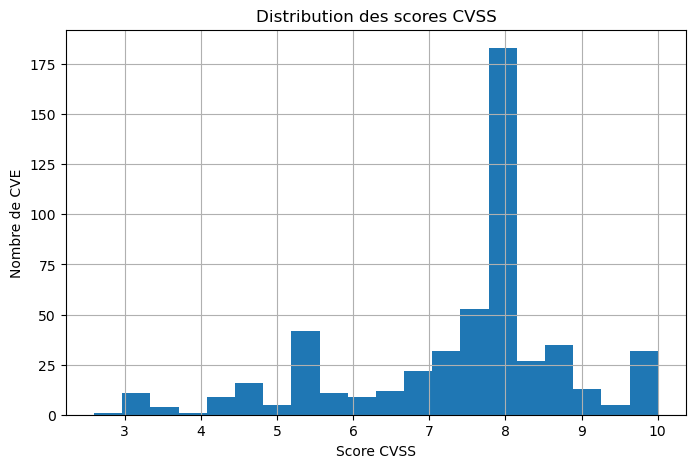

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df_viz["CVSS"].hist(bins=20)
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de CVE")
plt.show()

## Interprétation
Cet histogramme montre la répartition des vulnérabilités selon leur score CVSS.  
Les scores élevés correspondent à des vulnérabilités techniquement graves. On observe que plusieurs CVE se situent dans les catégories High et Critical, ce qui signifie qu’elles nécessitent une attention particulière dans une stratégie de cybersécurité.

## Distribution des scores EPSS

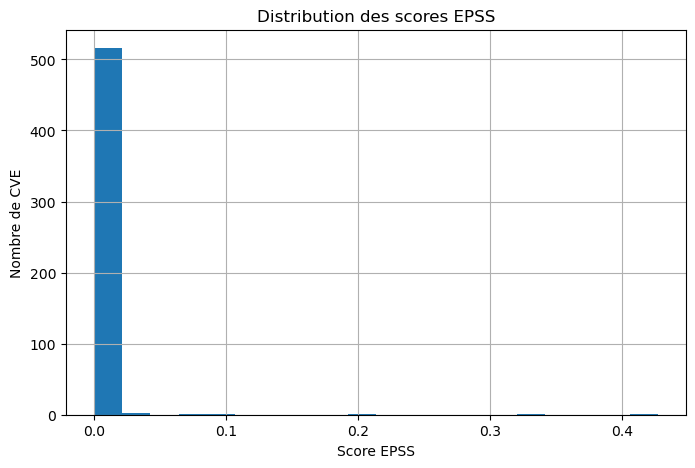

In [4]:
plt.figure(figsize=(8,5))
df_viz["EPSS"].hist(bins=20)
plt.title("Distribution des scores EPSS")
plt.xlabel("Score EPSS")
plt.ylabel("Nombre de CVE")
plt.show()

## Interprétation

Le score EPSS représente la probabilité qu’une vulnérabilité soit exploitée.  
On observe généralement que beaucoup de CVE ont un EPSS faible. Cela signifie qu’une vulnérabilité peut être grave techniquement sans être forcément fortement exploitée dans la réalité.

Les CVE avec un EPSS élevé doivent être priorisées, car elles représentent un risque d’exploitation plus concret.

## Répartition des vulnérabilités par sévérité

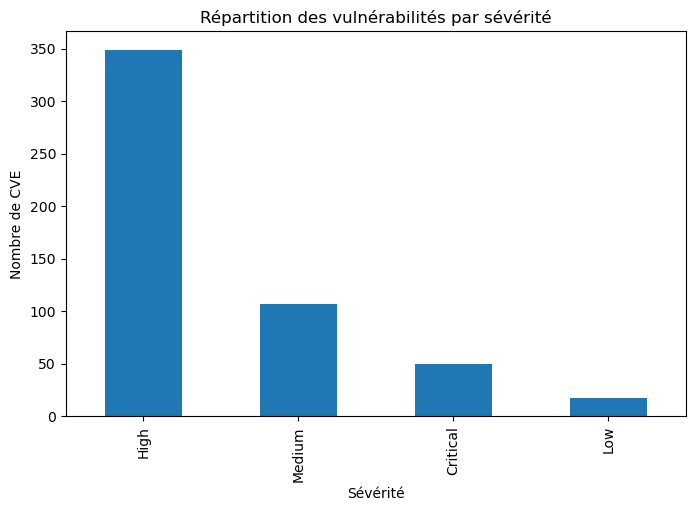

In [5]:
plt.figure(figsize=(8,5))
df_viz["Severity"].value_counts().plot(kind="bar")
plt.title("Répartition des vulnérabilités par sévérité")
plt.xlabel("Sévérité")
plt.ylabel("Nombre de CVE")
plt.show()

## Interprétation

Ce graphique permet d’identifier rapidement les niveaux de gravité les plus fréquents.  
Les vulnérabilités classées High et Medium sont les plus importantes à surveiller, car elles représentent un risque technique élevé pour les systèmes affectés.

## Top 10 des produits les plus affectés

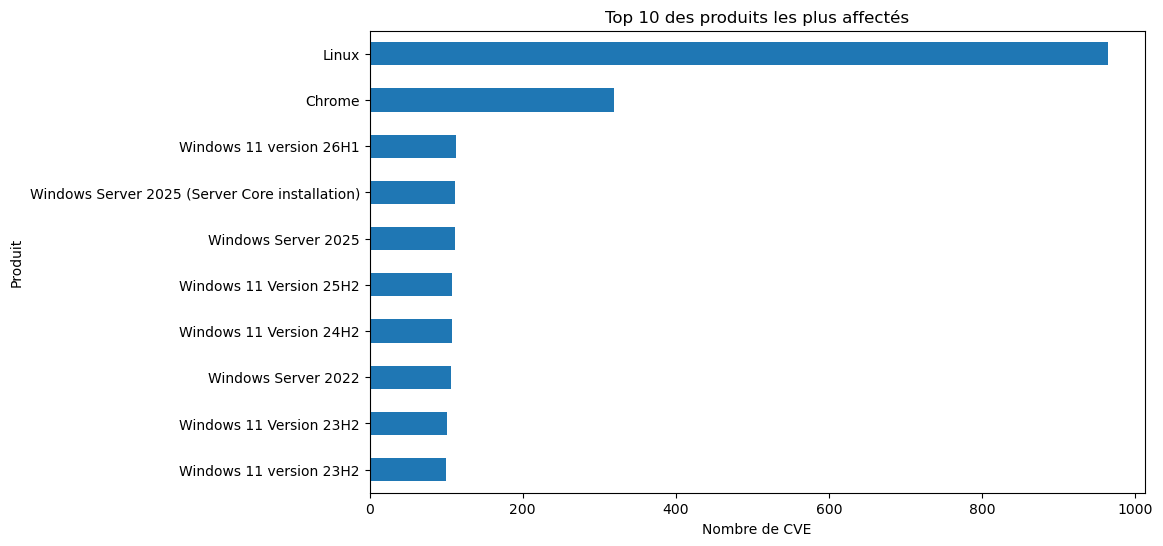

In [6]:
# Top 10 des produits les plus affectés

products = (
    df["Products"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_products = products.value_counts().head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 des produits les plus affectés")
plt.xlabel("Nombre de CVE")
plt.ylabel("Produit")
plt.show()

## Interprétation

Ce classement permet d’identifier les produits les plus touchés par les vulnérabilités.  
Cette information est importante pour orienter les actions de sécurité vers les logiciels ou systèmes les plus exposés.

## Nuage de points CVSS vs EPSS

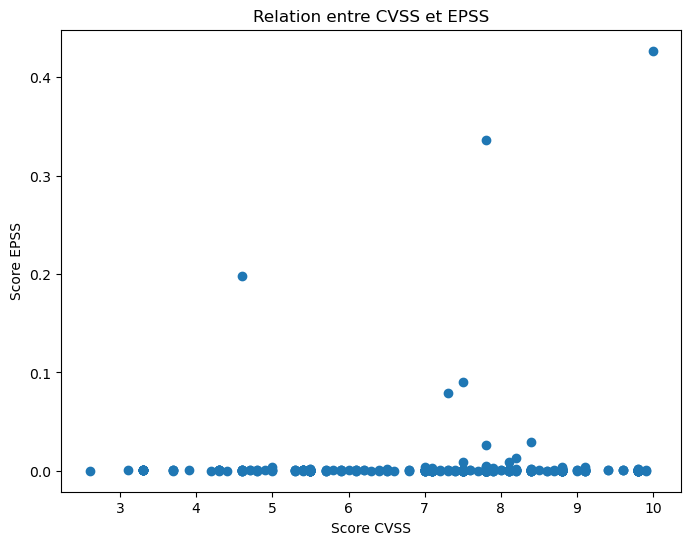

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(df_viz["CVSS"], df_viz["EPSS"])
plt.title("Relation entre CVSS et EPSS")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.show()

## Interprétation

Ce nuage de points compare la gravité technique d’une vulnérabilité avec sa probabilité d’exploitation.  
On observe que certaines CVE peuvent avoir un score CVSS élevé mais un score EPSS faible. Cela montre que le CVSS et l’EPSS apportent deux informations complémentaires.

Les vulnérabilités les plus prioritaires sont celles qui combinent un CVSS élevé et un EPSS élevé. Elles représentent à la fois une forte gravité technique et une forte probabilité d’exploitation.

## Heatmap de corrélation CVSS / EPSS

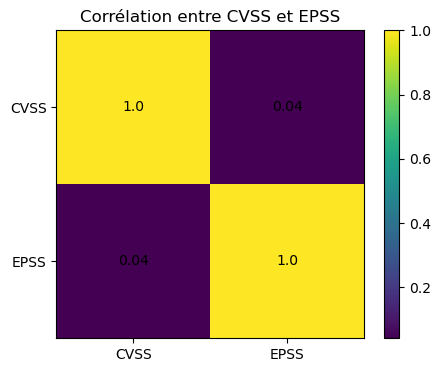

In [8]:
corr = df_viz[["CVSS", "EPSS"]].corr()

plt.figure(figsize=(5,4))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Corrélation entre CVSS et EPSS")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")

plt.show()

La corrélation permet d’observer si les vulnérabilités les plus graves techniquement sont aussi celles qui ont la plus forte probabilité d’exploitation. Une corrélation faible signifie que le CVSS et l’EPSS apportent deux informations complémentaires.

## Nombre de CVE uniques par mois

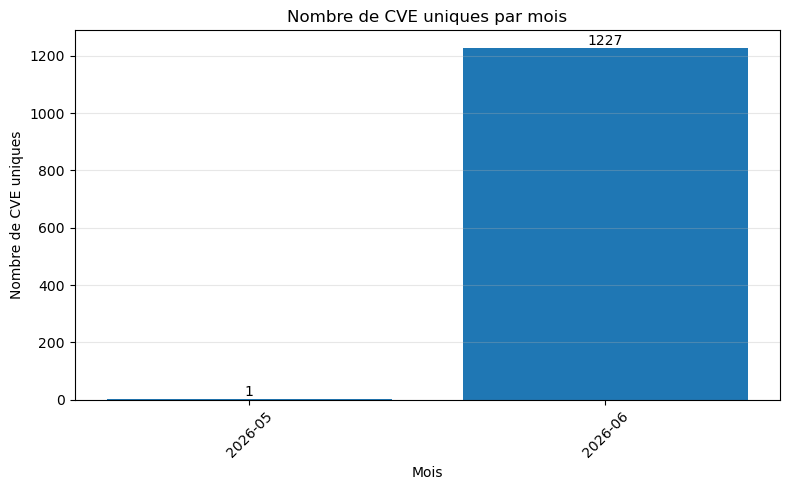

   Year  Month  count YearMonth
0  2026      5      1   2026-05
1  2026      6   1227   2026-06


In [16]:
vuln_by_month = (
    df.dropna(subset=["CVE"])
      .drop_duplicates(subset=["CVE", "Month", "Year"])
      .groupby(["Year", "Month"])
      .size()
      .reset_index(name="count")
)

vuln_by_month["YearMonth"] = vuln_by_month["Year"].astype(str) + "-" + vuln_by_month["Month"].astype(str).str.zfill(2)

plt.figure(figsize=(8, 5))
bars = plt.bar(vuln_by_month["YearMonth"], vuln_by_month["count"])

plt.title("Nombre de CVE uniques par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de CVE uniques")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print(vuln_by_month)

## Interprétation

Ce graphique montre l’évolution du nombre de CVE uniques par mois.  
Il permet d’identifier les périodes où le volume de vulnérabilités recensées est le plus important.

Dans notre jeu de données, les vulnérabilités sont fortement concentrées sur une période courte, ce qui peut s’expliquer par la période de collecte des bulletins.

## Top 10 des types CWE 

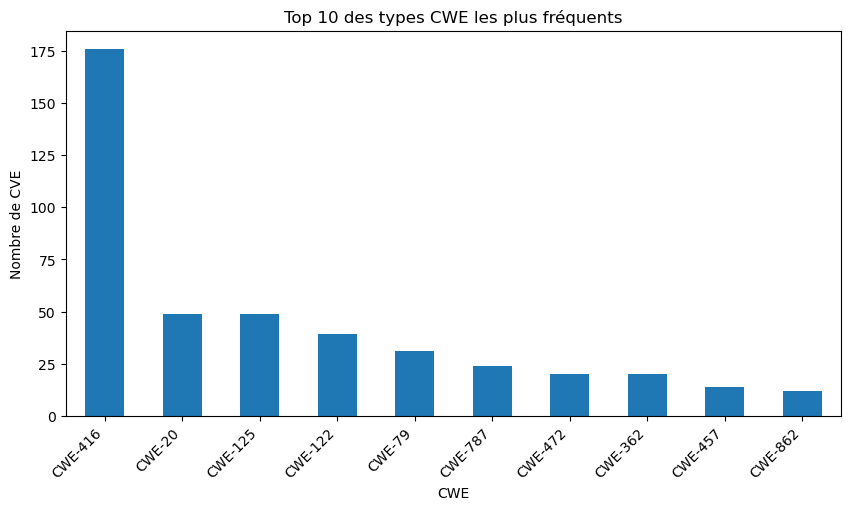

In [17]:
top_cwe = df["CWE"].dropna().value_counts().head(10)

plt.figure(figsize=(10,5))
top_cwe.plot(kind="bar")
plt.title("Top 10 des types CWE les plus fréquents")
plt.xlabel("CWE")
plt.ylabel("Nombre de CVE")
plt.xticks(rotation=45, ha="right")
plt.show()

Les CWE permettent d’identifier les familles de faiblesses les plus fréquentes. Cette analyse aide à comprendre la nature des vulnérabilités rencontrées, par exemple des erreurs mémoire, des problèmes d’authentification ou des injections.

## Courbe des scores EPSS triés

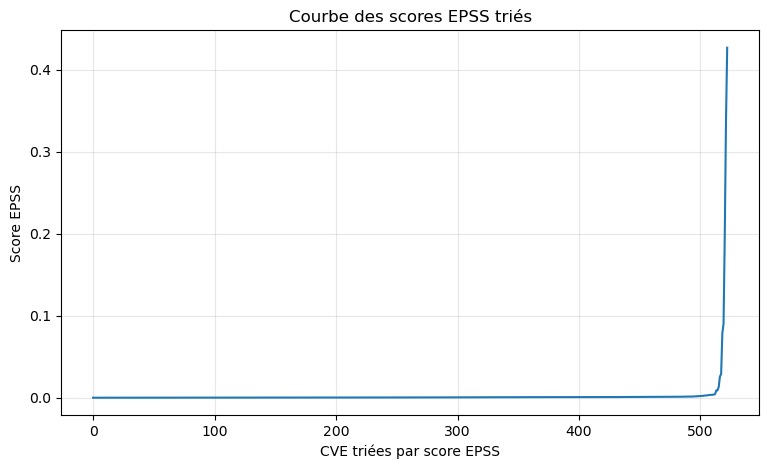

In [18]:
epss_sorted = df_viz["EPSS"].sort_values().reset_index(drop=True)

plt.figure(figsize=(9, 5))
plt.plot(epss_sorted)

plt.title("Courbe des scores EPSS triés")
plt.xlabel("CVE triées par score EPSS")
plt.ylabel("Score EPSS")
plt.grid(True, alpha=0.3)
plt.show()

## Interprétation

Cette courbe permet de visualiser la progression des scores EPSS.  
Elle montre si la majorité des vulnérabilités ont une faible probabilité d’exploitation ou si certaines CVE se démarquent avec un risque beaucoup plus élevé.

Cette information est utile pour prioriser les vulnérabilités les plus susceptibles d’être exploitées.

## Diagramme circulaire des CWE

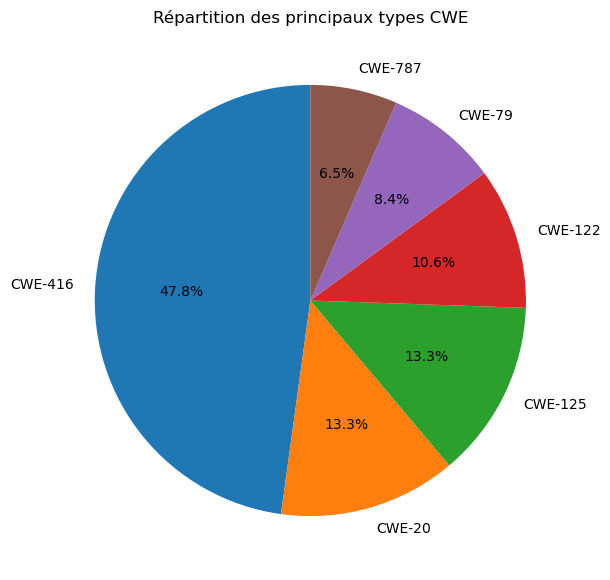

In [19]:
top_cwe_pie = df["CWE"].dropna().value_counts().head(6)

plt.figure(figsize=(7, 7))
plt.pie(
    top_cwe_pie.values,
    labels=top_cwe_pie.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des principaux types CWE")
plt.show()

## Interprétation

Ce diagramme circulaire montre la part des principaux types CWE parmi les vulnérabilités renseignées.  
Il permet de visualiser rapidement quelles familles de faiblesses dominent dans le jeu de données.

## Top 10 des éditeurs les plus affectés

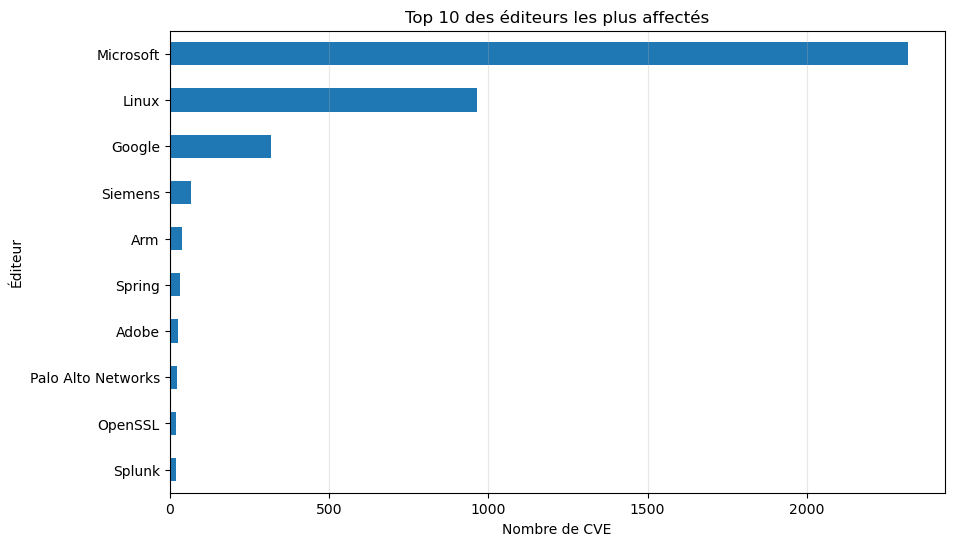

Vendors
Microsoft             2316
Linux                  964
Google                 319
Siemens                 67
Arm                     40
Spring                  32
Adobe                   27
Palo Alto Networks      24
Splunk                  20
OpenSSL                 20
Name: count, dtype: int64


In [20]:
vendors = (
    df["Vendors"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_vendors = vendors.value_counts().head(10)

plt.figure(figsize=(10, 6))
top_vendors.sort_values().plot(kind="barh")

plt.title("Top 10 des éditeurs les plus affectés")
plt.xlabel("Nombre de CVE")
plt.ylabel("Éditeur")
plt.grid(axis="x", alpha=0.3)
plt.show()

print(top_vendors)

## Interprétation

Ce graphique met en évidence les éditeurs les plus fréquemment associés aux vulnérabilités recensées.  
Les éditeurs présents en haut du classement peuvent nécessiter une surveillance plus importante, car leurs produits apparaissent plus souvent dans les bulletins de sécurité étudiés.

## Boxplot des scores CVSS par éditeur

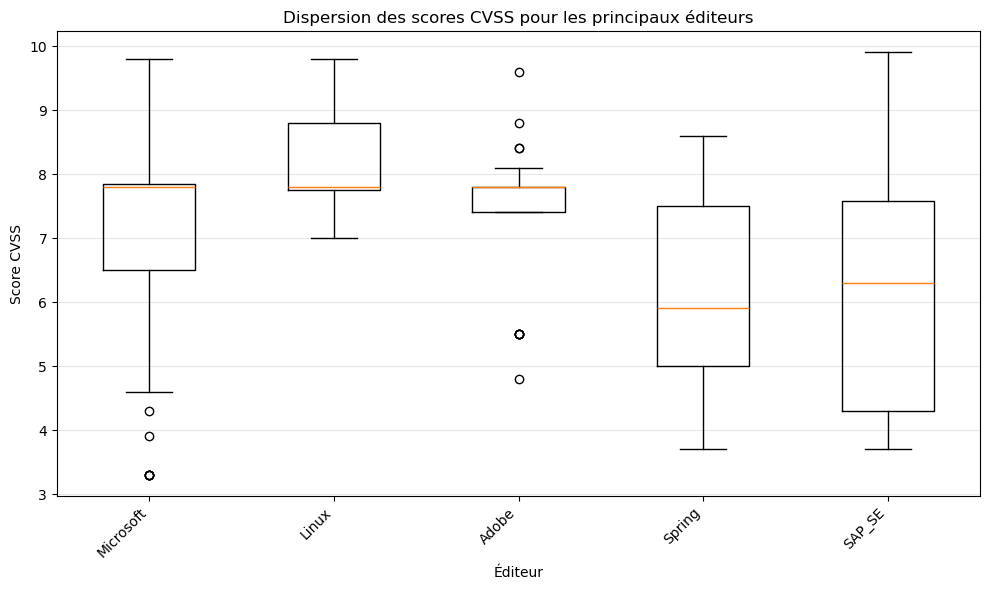

In [21]:
# Préparation des données avec un seul éditeur principal par ligne
df_box = df_viz.dropna(subset=["Vendors", "CVSS"]).copy()

# On prend le premier éditeur quand plusieurs éditeurs sont présents dans une même cellule
df_box["MainVendor"] = df_box["Vendors"].str.split(",").str[0].str.strip()

# Sélection des 5 éditeurs les plus fréquents
top_5_vendors = df_box["MainVendor"].value_counts().head(5).index

# Filtrer uniquement ces éditeurs
df_box_top = df_box[df_box["MainVendor"].isin(top_5_vendors)]

# Préparer les données pour le boxplot
data_boxplot = [
    df_box_top[df_box_top["MainVendor"] == vendor]["CVSS"]
    for vendor in top_5_vendors
]

# Création du boxplot
plt.figure(figsize=(10, 6))

plt.boxplot(
    data_boxplot,
    tick_labels=top_5_vendors
)

plt.title("Dispersion des scores CVSS pour les principaux éditeurs")
plt.xlabel("Éditeur")
plt.ylabel("Score CVSS")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Interprétation

Ce boxplot permet d’analyser la dispersion des scores CVSS pour les éditeurs les plus représentés.  
Il ne montre pas seulement le nombre de vulnérabilités, mais aussi leur niveau de gravité.

Un éditeur peut apparaître souvent, mais avec des vulnérabilités modérées ; à l’inverse, un autre peut apparaître moins souvent mais avec des CVE plus critiques.

## Tableau des CVE prioritaires

In [22]:
# Création d'un score de priorité
df_viz["RiskScore"] = df_viz["CVSS"] * df_viz["EPSS"]

priority_cves_display = df_viz.sort_values(
    by="RiskScore",
    ascending=False
)[
    ["CVE", "Title", "CVSS", "Severity", "EPSS", "RiskScore", "CWE", "Vendors", "Products", "Bulletin Link"]
].head(10)

priority_cves_display

,CVE,Title,CVSS,Severity,EPSS,RiskScore,CWE,Vendors,Products,Bulletin Link
479,CVE-2026-10520,Multiples vulnérabilités dans les produits Mic...,10.0,Critical,0.42699,4.269900,CWE-78,ivanti,Sentry,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
903,CVE-2026-23392,Multiples vulnérabilités dans le noyau Linux d...,7.8,High,0.33658,2.625324,NaN,"Linux, Linux","Linux, Linux",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
324,CVE-2026-45467,Multiples vulnérabilités dans les produits Mic...,4.6,Medium,0.19819,0.911674,CWE-79,"Microsoft, Microsoft, Microsoft","Microsoft SharePoint Enterprise Server 2016, M...",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
942,CVE-2026-22992,Multiples vulnérabilités dans le noyau Linux d...,7.5,High,0.09061,0.679575,NaN,"Linux, Linux","Linux, Linux",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
381,CVE-2026-47634,Multiples vulnérabilités dans les produits Mic...,7.3,High,0.07856,0.573488,CWE-74,"Microsoft, Microsoft","Microsoft SharePoint Server 2019, Microsoft Sh...",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
1067,CVE-2026-23172,Multiples vulnérabilités dans le noyau Linux d...,8.4,High,0.02889,0.242676,NaN,"Linux, Linux","Linux, Linux",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
1029,CVE-2026-31431,Multiples vulnérabilités dans le noyau Linux d...,7.8,High,0.02579,0.201162,NaN,"Linux, Linux","Linux, Linux",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
308,CVE-2026-46037,Multiples vulnérabilités dans les produits Mic...,8.2,High,0.01298,0.106436,NaN,"Linux, Linux","Linux, Linux",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
133,CVE-2026-42987,Multiples vulnérabilités dans Microsoft Window...,8.1,High,0.00898,0.072738,CWE-416,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...","Windows Server 2012, Windows Server 2012 (Serv...",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...
1268,CVE-2024-12905,Multiples vulnérabilités dans les produits IBM...,7.5,High,0.00885,0.066375,CWE-59,NaN,NaN,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...


## Interprétation
Ce tableau permet de prioriser les CVE en tenant compte à la fois de leur gravité CVSS et de leur probabilité d’exploitation EPSS. Les CVE avec le score de risque le plus élevé sont celles qui doivent être traitées en premier. Cela aide à passer d’une simple analyse descriptive à une décision de sécurité concrète.

## Courbe cumulative des vulnérabilités

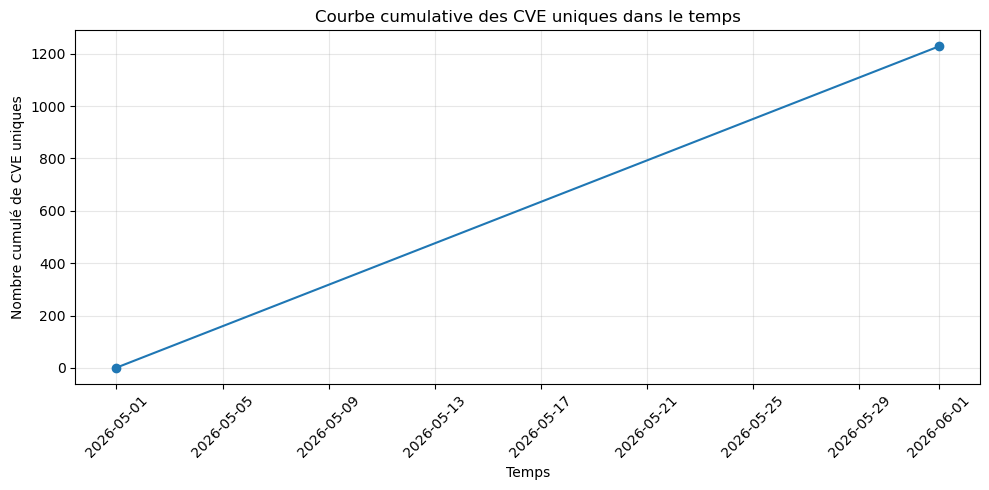

        date  count  cumulative
0 2026-05-01      1           1
1 2026-06-01   1227        1228


In [25]:
vuln_by_month = (
    df.dropna(subset=["CVE"])
      .drop_duplicates(subset=["CVE", "Month", "Year"])
      .groupby(["Year", "Month"])
      .size()
      .reset_index(name="count")
)

vuln_by_month["date"] = pd.to_datetime(
    vuln_by_month["Year"].astype(str) + "-" +
    vuln_by_month["Month"].astype(str).str.zfill(2) + "-01"
)

vuln_by_month = vuln_by_month.sort_values("date")
vuln_by_month["cumulative"] = vuln_by_month["count"].cumsum()

plt.figure(figsize=(10, 5))

plt.plot(
    vuln_by_month["date"],
    vuln_by_month["cumulative"],
    marker="o"
)

plt.title("Courbe cumulative des CVE uniques dans le temps")
plt.xlabel("Temps")
plt.ylabel("Nombre cumulé de CVE uniques")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(vuln_by_month[["date", "count", "cumulative"]])

## Interprétation
La courbe cumulative montre l’évolution progressive du nombre total de CVE uniques recensées.  
Elle permet de visualiser l’accumulation des vulnérabilités au fil du temps et de mieux comprendre la dynamique de détection des failles.

## Top 10 des versions les plus touchées 

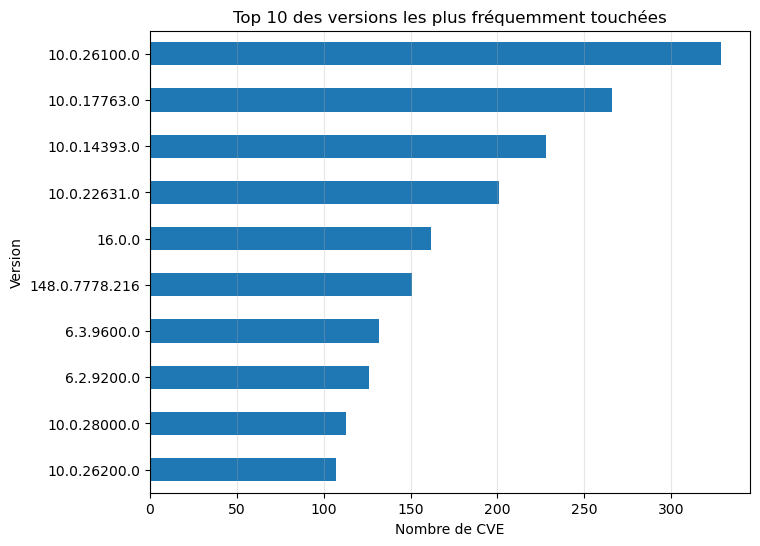

Versions
10.0.26100.0      329
10.0.17763.0      266
10.0.14393.0      228
10.0.22631.0      201
16.0.0            162
148.0.7778.216    151
6.3.9600.0        132
6.2.9200.0        126
10.0.28000.0      113
10.0.26200.0      107
Name: count, dtype: int64


In [26]:
import matplotlib.pyplot as plt

# Séparer correctement les versions avec "," ou "|"
versions = (
    df["Versions"]
    .dropna()
    .astype(str)
    .str.split(r",|\|", regex=True)
    .explode()
    .str.strip()
)

# Supprimer les valeurs vides, inutiles ou non interprétables
versions = versions[
    (versions != "") &
    (versions != "-") &
    (versions != "0") &
    (versions.str.lower() != "nan") &
    (versions.str.lower() != "unavailable") &
    (versions.str.lower() != "non disponible")
]

# Supprimer les valeurs trop longues, souvent des hashs ou chaînes peu lisibles
versions = versions[versions.str.len() <= 25]

# Top 10 des versions les plus fréquentes
top_versions = versions.value_counts().head(10)

# Graphique propre
plt.figure(figsize=(10, 6))
top_versions.sort_values().plot(kind="barh")

plt.title("Top 10 des versions les plus fréquemment touchées")
plt.xlabel("Nombre de CVE")
plt.ylabel("Version")
plt.grid(axis="x", alpha=0.3)
plt.subplots_adjust(left=0.30)
plt.show()

print(top_versions)

## Interprétation
Cette visualisation montre les versions les plus fréquemment associées aux vulnérabilités.  
Elle peut aider à cibler les versions de produits nécessitant une mise à jour ou une surveillance particulière.

# Machine Learning
## Apprentissage supervisé: Prediction du score EPSS

L'EPSS mesure la probabilité qu'une vulnérabilité soit exploitée dans un futur proche. Le prédire permet d'identifier rapidement les vulnérabilités les plus dangereuses et d'aider les équipes de cybersécurité à prioriser leurs actions de correction.

In [27]:
import pandas as pd
import numpy as np
 
# Chargement
df = pd.read_csv(
    "ANSSI_cleaned.csv",
    sep=";",
    encoding="utf-8",
    on_bad_lines="skip",
)

df = df.dropna(subset=["EPSS"])
df.shape

(1259, 18)

In [28]:
df["Vendor"] = (
    df["Vendors"]
    .fillna("Unknown")
    .str.split(",")
    .str[0]
    .str.strip()
)

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = [
    "CVSS",
    "Type",
    "Severity",
    "CWE",
    "Vendor",
    "Year",
    "Month"
]

X = df[features]
y = df["EPSS"]


num_features = [
    "CVSS",
    "Year",
    "Month"
]

cat_features = [
    "Type",
    "Severity",
    "CWE",
    "Vendor"
]

### Préprocessing

In [30]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

In [31]:

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])


### Train test split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Entraînement

In [33]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluation

In [38]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

MAE  : 0.0016
RMSE : 0.0052


## Apprentissage non supervise: Clustering de vulnérabilités

Le clustering par K-Means a été utilisé afin d'identifier des groupes naturels de vulnérabilités partageant des caractéristiques similaires. En s'appuyant sur le score CVSS, le score EPSS et le type de faiblesse CWE, cette approche permet de mettre en évidence différents profils de risque sans disposer d'étiquettes prédéfinies. Les clusters obtenus peuvent ensuite être utilisés pour améliorer la priorisation des vulnérabilités et mieux comprendre les différentes catégories de menaces présentes dans les données.

In [39]:
features = [
    "CVSS",
    "EPSS",
    "CWE"
]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["CWE_encoded"] = le.fit_transform(
    df["CWE"].fillna("Unknown")
)

### Processing

In [40]:
from sklearn.preprocessing import StandardScaler

X = df[["CVSS", "EPSS", "CWE_encoded"]]

X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Clustering KMeans

In [41]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans

### Trouver le bon nombre de cluster

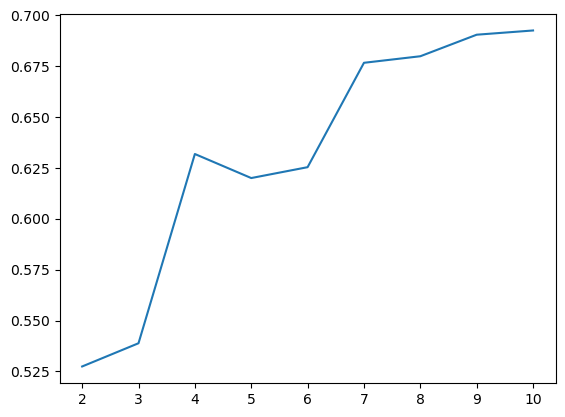

In [42]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []
K = range(2, 11)
for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(K,scores)
plt.show()

In [43]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

## Evaluation

In [44]:
score = silhouette_score(X_scaled, df["Cluster"])

print(f"Silhouette Score : {score:.3f}")

Silhouette Score : 0.527
